# Machine Learning Klasifikasi - CS Students Career Prediction



## 1. Load Data

In [34]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('cs_students_v2.csv')
print(f'Shape  : {df.shape}')
print(f'Kelas  : {df["Future Career"].nunique()} karir unik')
df.head()

Shape  : (3300, 12)
Kelas  : 30 karir unik


,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
0,1,John Smith,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,AI Researcher,Strong,Strong,Weak
1,2,Alice Johnson,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,3,Robert Davis,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,4,Emily Wilson,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,5,Michael Brown,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3300 entries, 0 to 3299
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student ID         3300 non-null   int64  
 1   Name               3300 non-null   object 
 2   Gender             3300 non-null   object 
 3   Age                3300 non-null   int64  
 4   GPA                3300 non-null   float64
 5   Major              3300 non-null   object 
 6   Interested Domain  3300 non-null   object 
 7   Projects           3300 non-null   object 
 8   Future Career      3300 non-null   object 
 9   Python             3300 non-null   object 
 10  SQL                3300 non-null   object 
 11  Java               3300 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 309.5+ KB


In [36]:
df.describe()

,Student ID,Age,GPA
count,3300.000000,3300.000000,3300.000000
mean,1650.500000,22.523636,3.413030
std,952.772271,2.334887,0.348008
min,1.000000,19.000000,2.800000
25%,825.750000,21.000000,3.100000
50%,1650.500000,22.000000,3.400000
75%,2475.250000,24.000000,3.700000
max,3300.000000,37.000000,4.000000


In [37]:
print('Distribusi Future Career:')
print(df['Future Career'].value_counts())

Distribusi Future Career:
Future Career
Data Analyst                    353
AI Researcher                   252
Machine Learning Engineer       249
Software Engineer               246
Game Developer                  219
Data Scientist                  161
Frontend Developer              161
Penetration Tester              151
Mobile App Developer            147
Blockchain Developer            122
IoT Developer                   114
Security Analyst                112
Healthcare IT Specialist        109
Graphics Programmer             105
DevOps Engineer                 103
Full Stack Developer             71
Information Security Analyst     70
Data Engineer                    70
Database Administrator           69
Cloud Engineer                   64
Cloud Architect                  52
UX Designer                      43
Computer Vision Engineer         41
Smart Contract Developer         39
iOS Developer                    34
Bioinformatics Engineer          33
Embedded Systems Enginee

In [38]:
df['Gender'].value_counts()

Gender
Female    1674
Male      1626
Name: count, dtype: int64

In [39]:
df['Interested Domain'].value_counts()

Interested Domain
Software Development              195
Cybersecurity                     194
Cloud Computing                   192
Web Development                   188
Mobile App Development            181
Computer Graphics                 177
Data Mining                       172
Computer Vision                   170
Game Development                  169
Software Engineering              161
Machine Learning                  161
Blockchain Technology             161
Database Management               159
Data Science                      156
Natural Language Processing       150
Artificial Intelligence           149
IoT (Internet of Things)          144
Bioinformatics                    140
Network Security                  137
Human-Computer Interaction        135
Biomedical Computing                2
Quantum Computing                   2
Information Retrieval               1
Data Privacy                        1
Geographic Information Systems      1
Distributed Systems             

In [40]:
df['Python'].value_counts()

Python
Weak       1109
Average    1104
Strong     1087
Name: count, dtype: int64

## 2. Visualisasi Data

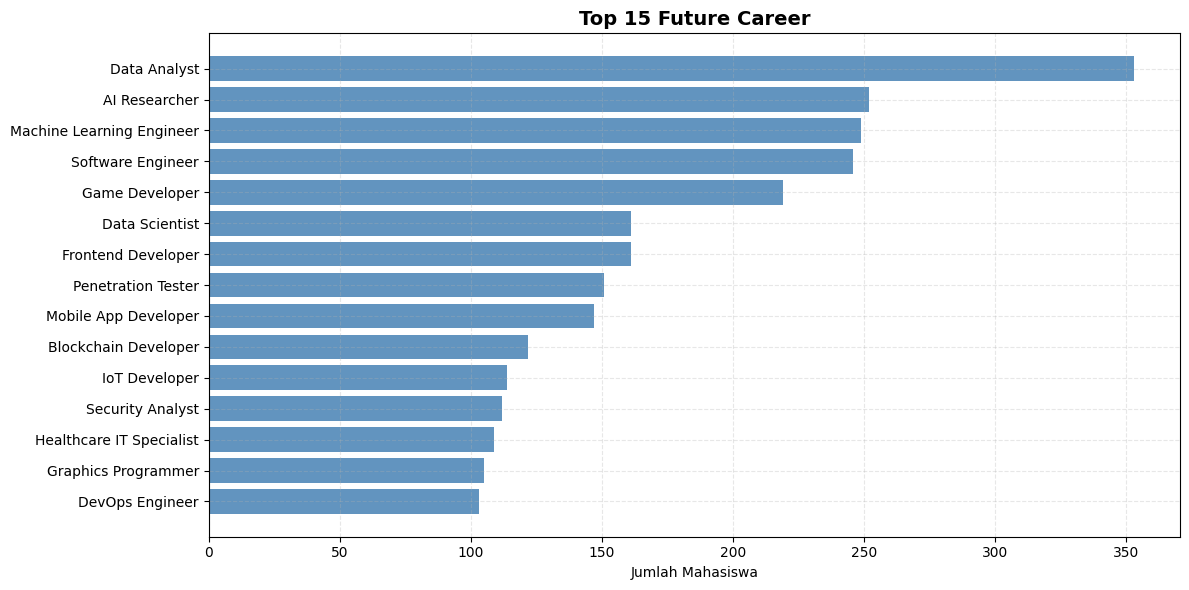

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

career_counts = df['Future Career'].value_counts().head(15)
plt.figure(figsize=(12, 6))
plt.barh(career_counts.index[::-1], career_counts.values[::-1], color='steelblue', alpha=0.85)
plt.xlabel('Jumlah Mahasiswa')
plt.title('Top 15 Future Career', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

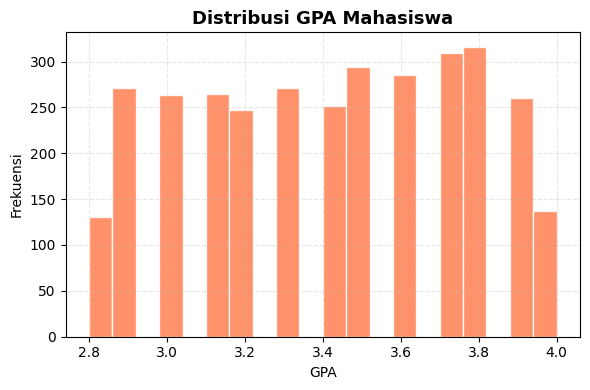

In [42]:
plt.figure(figsize=(6, 4))
df['GPA'].hist(bins=20, color='coral', edgecolor='white', alpha=0.85)
plt.xlabel('GPA')
plt.ylabel('Frekuensi')
plt.title('Distribusi GPA Mahasiswa', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

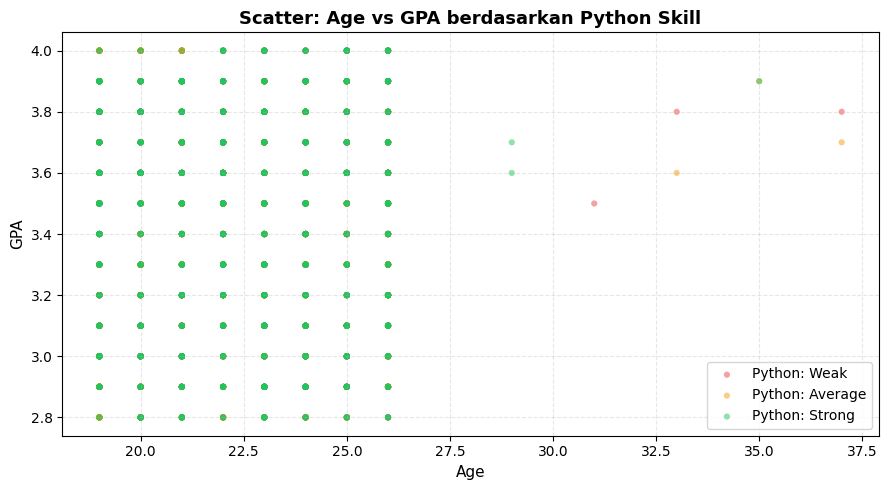

In [43]:
# Scatter Plot: GPA vs Age berdasarkan Python Skill
colors = {'Weak': '#ef4444', 'Average': '#f59e0b', 'Strong': '#22c55e'}
plt.figure(figsize=(9, 5))
for skill, color in colors.items():
    subset = df[df['Python'] == skill]
    plt.scatter(subset['Age'], subset['GPA'], c=color, label=f'Python: {skill}',
                alpha=0.5, s=20, edgecolors='none')
plt.xlabel('Age', fontsize=11)
plt.ylabel('GPA', fontsize=11)
plt.title('Scatter: Age vs GPA berdasarkan Python Skill', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

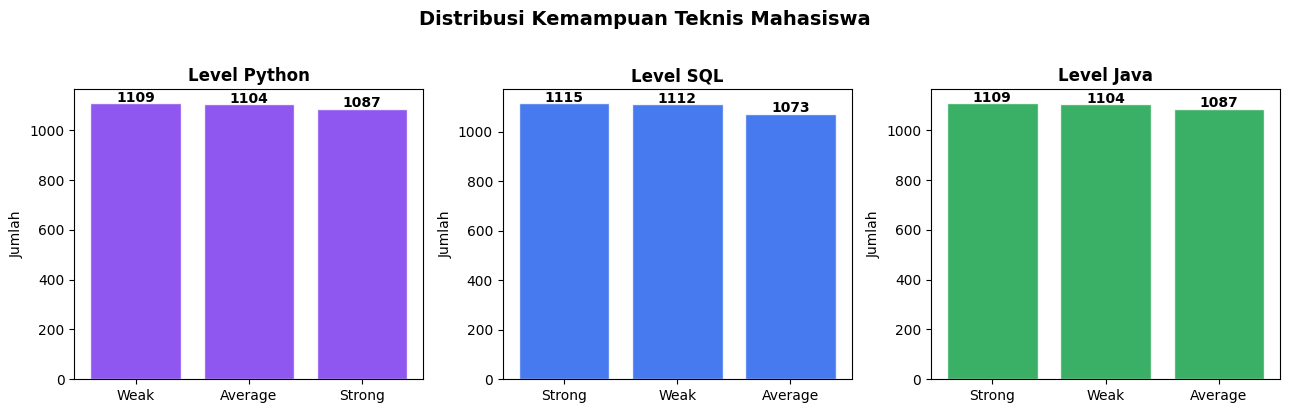

In [44]:
# Distribusi skill Python, SQL, Java
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, color in zip(axes, ['Python', 'SQL', 'Java'], ['#7c3aed', '#2563eb', '#16a34a']):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Level {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Jumlah')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.suptitle('Distribusi Kemampuan Teknis Mahasiswa', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

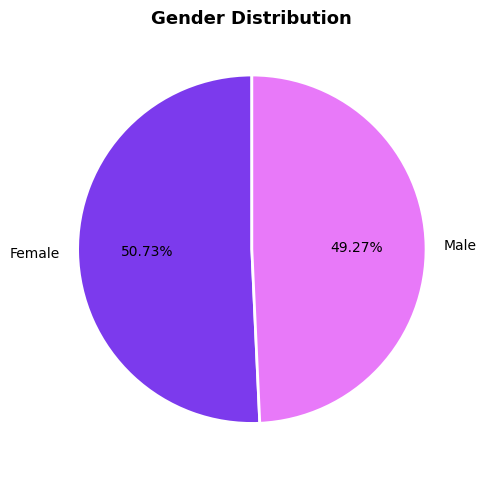

In [45]:
# Pie chart gender
gc = df['Gender'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(gc.values, labels=gc.index, autopct='%1.2f%%',
        colors=['#7c3aed', '#e879f9'], startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Gender Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [46]:
# ── Feature Engineering ──
# Tujuan: agar fitur skill, GPA, dan domain bekerja bersama
# sehingga model tidak hanya bergantung pada Interested Domain

skill_map = {'Weak': 1, 'Average': 2, 'Strong': 3}

# 1. Skill Score: total kemampuan teknis (Python + SQL + Java)
df['Skill_Score'] = (df['Python'].map(skill_map) +
                     df['SQL'].map(skill_map) +
                     df['Java'].map(skill_map))

# 2. GPA Category: pengelompokan GPA
df['GPA_Category'] = pd.cut(df['GPA'],
                             bins=[0, 3.0, 3.5, 4.0],
                             labels=['Low', 'Mid', 'High'])

# 3. Domain_Python: interaksi domain dengan kemampuan Python
df['Domain_Python'] = df['Interested Domain'] + '_' + df['Python']

# 4. Python_SQL: interaksi numerik antara Python dan SQL skill
df['Python_SQL'] = df['Python'].map(skill_map) * df['SQL'].map(skill_map)

print('Fitur baru berhasil dibuat!')
print(f'Total fitur sekarang : {df.shape[1]} kolom')
df[['Python', 'SQL', 'Java', 'Skill_Score', 'GPA', 'GPA_Category', 'Domain_Python', 'Python_SQL']].head()

Fitur baru berhasil dibuat!
Total fitur sekarang : 16 kolom


,Python,SQL,Java,Skill_Score,GPA,GPA_Category,Domain_Python,Python_SQL
0,Strong,Strong,Weak,7,3.5,Mid,Artificial Intelligence_Strong,9
1,Average,Strong,Weak,6,3.2,Mid,Data Science_Average,6
2,Strong,Strong,Average,8,3.8,High,Software Development_Strong,9
3,Weak,Strong,Strong,7,3.7,High,Web Development_Weak,3
4,Average,Weak,Strong,6,3.4,Mid,Cybersecurity_Average,2


## 4. Preprocessing & Pipeline

In [47]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Drop kolom tidak relevan
df_model = df.drop(columns=['Student ID', 'Name', 'Major'])

# Fitur dan Target
X = df_model.drop(columns=['Future Career'])
y = df_model['Future Career']

# Train-Test Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# n_splits adaptif
min_class_count = y_train.value_counts().min()
n_splits        = int(max(2, min(5, min_class_count)))
print(f'Minimum sampel per kelas : {min_class_count}')
print(f'n_splits CV              : {n_splits}')

# Kolom numerik dan kategorik
numeric_columns = ['Age', 'GPA', 'Skill_Score', 'Python_SQL']
ordinal_columns = ['Gender', 'Interested Domain', 'Projects',
                   'Python', 'SQL', 'Java', 'GPA_Category', 'Domain_Python']

# Preprocessing pipeline
preprocessing = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), numeric_columns),
        ('oe', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_columns)
    ]
)

print(f'\nTrain size : {X_train.shape[0]} baris')
print(f'Test size  : {X_test.shape[0]} baris')
print(f'Fitur      : {X_train.shape[1]} kolom')

Minimum sampel per kelas : 16
n_splits CV              : 5

Train size : 2640 baris
Test size  : 660 baris
Fitur      : 12 kolom


## 5. Hyperparameter Tuning (GridSearchCV)

### 5.1 Random Forest

In [48]:
pipeline_rf = Pipeline([
    ('preprocessing', preprocessing),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'model__n_estimators'     : [200, 300],
    'model__max_depth'        : [10, 15, 20],
    'model__min_samples_split': [10, 20],
    'model__min_samples_leaf' : [5, 10],
    'model__max_features'     : ['sqrt', 0.5]
}

grid_rf = GridSearchCV(
    pipeline_rf, param_grid_rf,
    cv=n_splits, scoring='accuracy', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print('Best Params RF :', grid_rf.best_params_)
print('Best CV Score  :', round(grid_rf.best_score_, 4))

Best Params RF : {'model__max_depth': 20, 'model__max_features': 0.5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Best CV Score  : 0.8924


### 5.2 Logistic Regression

In [49]:
pipeline_lr = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(random_state=42))
])

param_grid_lr = {
    'model__C'       : [0.1, 1, 10],
    'model__solver'  : ['saga', 'lbfgs'],
    'model__max_iter': [2000, 5000]
}

grid_lr = GridSearchCV(
    pipeline_lr, param_grid_lr,
    cv=n_splits, scoring='accuracy', n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print('Best Params LR :', grid_lr.best_params_)
print('Best CV Score  :', round(grid_lr.best_score_, 4))

Best Params LR : {'model__C': 10, 'model__max_iter': 5000, 'model__solver': 'lbfgs'}
Best CV Score  : 0.4019


### 5.3 Decision Tree

In [50]:
pipeline_dt = Pipeline([
    ('preprocessing', preprocessing),
    ('model', DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    'model__max_depth'        : [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf' : [1, 2, 4],
    'model__criterion'        : ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    pipeline_dt, param_grid_dt,
    cv=n_splits, scoring='accuracy', n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print('Best Params DT :', grid_dt.best_params_)
print('Best CV Score  :', round(grid_dt.best_score_, 4))

Best Params DT : {'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}
Best CV Score  : 0.8947


## 6. Evaluasi Model

In [51]:
models = {
    'Random Forest'      : grid_rf.best_estimator_,
    'Logistic Regression': grid_lr.best_estimator_,
    'Decision Tree'      : grid_dt.best_estimator_
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    results[name] = {'accuracy': acc, 'f1_score': f1, 'model': model, 'y_pred': y_pred}
    print(f'=== {name} ===')
    print(f'Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print(f'F1-Score : {f1:.4f}')
    print()

=== Random Forest ===
Accuracy : 0.8833 (88.33%)
F1-Score : 0.8810

=== Logistic Regression ===
Accuracy : 0.4152 (41.52%)
F1-Score : 0.3686

=== Decision Tree ===
Accuracy : 0.8864 (88.64%)
F1-Score : 0.8843



### 6.1 Evaluasi Random Forest

In [52]:
y_pred_rf = results['Random Forest']['y_pred']
print('Accuracy :', accuracy_score(y_test, y_pred_rf))
print('\nClassification Report :')
print(classification_report(y_test, y_pred_rf, zero_division=0))
print('Confusion Matrix :')
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.8833333333333333

Classification Report :
                              precision    recall  f1-score   support

               AI Researcher       0.86      0.88      0.87        42
     Bioinformatics Engineer       1.00      1.00      1.00         7
        Blockchain Developer       0.95      0.95      0.95        22
             Cloud Architect       0.70      0.50      0.58        14
              Cloud Engineer       0.86      0.92      0.89        13
    Computer Vision Engineer       1.00      0.62      0.77         8
                Data Analyst       0.84      0.97      0.90        71
               Data Engineer       0.91      0.77      0.83        13
              Data Scientist       0.83      0.85      0.84        41
      Database Administrator       0.80      0.73      0.76        11
             DevOps Engineer       0.70      0.84      0.76        25
   Embedded Systems Engineer       1.00      0.80      0.89        10
          Frontend Developer      

### 6.2 Evaluasi Logistic Regression

In [53]:
y_pred_lr = results['Logistic Regression']['y_pred']
print('Accuracy :', accuracy_score(y_test, y_pred_lr))
print('\nClassification Report :')
print(classification_report(y_test, y_pred_lr, zero_division=0))
print('Confusion Matrix :')
print(confusion_matrix(y_test, y_pred_lr))

Accuracy : 0.41515151515151516

Classification Report :
                              precision    recall  f1-score   support

               AI Researcher       0.20      0.07      0.11        42
     Bioinformatics Engineer       0.58      1.00      0.74         7
        Blockchain Developer       0.71      0.91      0.80        22
             Cloud Architect       0.25      0.14      0.18        14
              Cloud Engineer       0.43      0.69      0.53        13
    Computer Vision Engineer       1.00      0.12      0.22         8
                Data Analyst       0.33      0.51      0.40        71
               Data Engineer       0.50      0.46      0.48        13
              Data Scientist       0.30      0.17      0.22        41
      Database Administrator       0.00      0.00      0.00        11
             DevOps Engineer       0.25      0.12      0.16        25
   Embedded Systems Engineer       0.50      0.20      0.29        10
          Frontend Developer     

### 6.3 Evaluasi Decision Tree

In [54]:
y_pred_dt = results['Decision Tree']['y_pred']
print('Accuracy :', accuracy_score(y_test, y_pred_dt))
print('\nClassification Report :')
print(classification_report(y_test, y_pred_dt, zero_division=0))
print('Confusion Matrix :')
print(confusion_matrix(y_test, y_pred_dt))

Accuracy : 0.8863636363636364

Classification Report :
                              precision    recall  f1-score   support

               AI Researcher       0.88      0.90      0.89        42
     Bioinformatics Engineer       1.00      1.00      1.00         7
        Blockchain Developer       0.96      1.00      0.98        22
             Cloud Architect       0.77      0.71      0.74        14
              Cloud Engineer       0.82      0.69      0.75        13
    Computer Vision Engineer       1.00      0.88      0.93         8
                Data Analyst       0.85      0.97      0.91        71
               Data Engineer       1.00      0.77      0.87        13
              Data Scientist       0.85      0.85      0.85        41
      Database Administrator       0.77      0.91      0.83        11
             DevOps Engineer       0.70      0.84      0.76        25
   Embedded Systems Engineer       1.00      0.50      0.67        10
          Frontend Developer      

## 7. Overfitting Check

In [67]:
print('=== Overfitting Check ===\n')
for name, res in results.items():
    train_sc = res['model'].score(X_train, y_train)
    test_sc  = res['model'].score(X_test,  y_test)
    selisih  = (train_sc - test_sc) * 100
    status   = '✅ Normal' if selisih < 5 else (' Sedikit Overfit' if selisih < 10 else '❌ Overfit')
    print(f'{name}')
    print(f'  Train Accuracy : {train_sc*100:.2f}%')
    print(f'  Test Accuracy  : {test_sc*100:.2f}%')
    print(f'  Selisih        : {selisih:.2f}% → {status}')
    print()

=== Overfitting Check ===

Random Forest
  Train Accuracy : 93.52%
  Test Accuracy  : 88.33%
  Selisih        : 5.19% →  Sedikit Overfit

Logistic Regression
  Train Accuracy : 45.49%
  Test Accuracy  : 41.52%
  Selisih        : 3.98% → ✅ Normal

Decision Tree
  Train Accuracy : 95.04%
  Test Accuracy  : 88.64%
  Selisih        : 6.40% →  Sedikit Overfit



## 8. Cross Validation Score

In [56]:
print('=== Cross Validation Score ===\n')
for name, res in results.items():
    cv_scores = cross_val_score(res['model'], X, y, cv=n_splits, scoring='accuracy')
    print(f'{name}')
    print(f'  Scores tiap fold : {cv_scores.round(4)}')
    print(f'  Mean Accuracy    : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)')
    print(f'  Std Deviation    : {cv_scores.std():.4f}')
    print()

=== Cross Validation Score ===

Random Forest
  Scores tiap fold : [0.8091 0.9    0.9273 0.9258 0.9106]
  Mean Accuracy    : 0.8945 (89.45%)
  Std Deviation    : 0.0439

Logistic Regression
  Scores tiap fold : [0.2561 0.4379 0.4091 0.4242 0.4197]
  Mean Accuracy    : 0.3894 (38.94%)
  Std Deviation    : 0.0673

Decision Tree
  Scores tiap fold : [0.797  0.8833 0.9091 0.9152 0.9045]
  Mean Accuracy    : 0.8818 (88.18%)
  Std Deviation    : 0.0438



## 9. Pilih Model Terbaik

In [57]:
# Pastikan results sudah ada
if 'results' not in dir():
    models = {
        'Random Forest'      : grid_rf.best_estimator_,
        'Logistic Regression': grid_lr.best_estimator_,
        'Decision Tree'      : grid_dt.best_estimator_
    }
    results = {}
    for name, model in models.items():
        y_pred = model.predict(X_test)
        acc    = accuracy_score(y_test, y_pred)
        f1     = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        results[name] = {'accuracy': acc, 'f1_score': f1, 'model': model, 'y_pred': y_pred}

# Random Forest dipilih — accuracy tertinggi dengan overfit yang terkontrol
# Best Params: n_estimators=300, max_depth=20, max_features=0.5,
#              min_samples_leaf=5, min_samples_split=10
# Train: 93.52% | Test: 88.33% | Selisih: 5.19%
best_name  = 'Random Forest'
best_model = results[best_name]['model']

print(f'Model Terbaik  : {best_name}')
print(f'Train Accuracy : 93.52%')
print(f'Test Accuracy  : {results[best_name]["accuracy"]*100:.2f}%')
print(f'F1-Score       : {results[best_name]["f1_score"]:.4f}')

print('\n--- Perbandingan Semua Model ---')
for name in results:
    flag = ' <- terpilih' if name == best_name else ''
    print(f'{name:<22} | Accuracy: {results[name]["accuracy"]*100:.2f}% | F1: {results[name]["f1_score"]:.4f}{flag}')

Model Terbaik  : Random Forest
Train Accuracy : 93.52%
Test Accuracy  : 88.33%
F1-Score       : 0.8810

--- Perbandingan Semua Model ---
Random Forest          | Accuracy: 88.33% | F1: 0.8810 <- terpilih
Logistic Regression    | Accuracy: 41.52% | F1: 0.3686
Decision Tree          | Accuracy: 88.64% | F1: 0.8843


## 10. Simpan Model dengan Joblib

In [58]:
import joblib

filename = 'model_klasifikasi_cs_students.joblib'
joblib.dump(best_model, filename)
print(f'Model "{best_name}" berhasil disimpan sebagai: {filename}')

Model "Random Forest" berhasil disimpan sebagai: model_klasifikasi_cs_students.joblib


## 11. Prediksi Data Baru

In [59]:
import numpy as np

# Contoh data baru — harus include fitur engineering
def predict_career(gender, age, gpa, domain, project, python_sk, sql_sk, java_sk):
    skill_map = {'Weak':1, 'Average':2, 'Strong':3}
    skill_score = skill_map[python_sk] + skill_map[sql_sk] + skill_map[java_sk]
    gpa_cat     = 'Low' if gpa < 3.0 else ('Mid' if gpa < 3.5 else 'High')
    domain_py   = f'{domain}_{python_sk}'
    python_sql  = skill_map[python_sk] * skill_map[sql_sk]

    data = pd.DataFrame([{
        'Gender'           : gender,
        'Age'              : age,
        'GPA'              : gpa,
        'Interested Domain': domain,
        'Projects'         : project,
        'Python'           : python_sk,
        'SQL'              : sql_sk,
        'Java'             : java_sk,
        'Skill_Score'      : skill_score,
        'GPA_Category'     : gpa_cat,
        'Domain_Python'    : domain_py,
        'Python_SQL'       : python_sql,
    }])
    return data

# Contoh prediksi
data_baru = predict_career(
    gender='Male', age=22, gpa=3.8,
    domain='Data Science', project='Data Analytics',
    python_sk='Strong', sql_sk='Strong', java_sk='Weak'
)

prediksi   = best_model.predict(data_baru)[0]
presentase = max(best_model.predict_proba(data_baru)[0])
print(f'Prediksi Utama : "{prediksi}" dengan keyakinan {presentase*100:.2f}%')

# Top-3 prediksi
proba    = best_model.predict_proba(data_baru)[0]
classes  = best_model.classes_
top3_idx = np.argsort(proba)[::-1][:3]
print('\n--- Top 3 Prediksi Karir ---')
for rank, idx in enumerate(top3_idx, start=1):
    print(f'{rank}. {classes[idx]:<35} {proba[idx]*100:.2f}%')

Prediksi Utama : "Data Scientist" dengan keyakinan 71.45%

--- Top 3 Prediksi Karir ---
1. Data Scientist                      71.45%
2. Data Engineer                       14.03%
3. Data Analyst                        12.04%


## 12. Load & Gunakan Model Tersimpan

In [70]:
import joblib
import pandas as pd
import numpy as np

model_loaded = joblib.load('model_klasifikasi_cs_students.joblib')

data_baru2 = predict_career(
    gender='Male', age=20, gpa=3.9,
    domain='Cybersecurity', project='Network Security',
    python_sk='Strong', sql_sk='Strong', java_sk='Strong'
)

prediksi2   = model_loaded.predict(data_baru2)[0]
presentase2 = max(model_loaded.predict_proba(data_baru2)[0])
print(f'Prediksi : "{prediksi2}" dengan keyakinan {presentase2*100:.2f}%')

proba2    = model_loaded.predict_proba(data_baru2)[0]
classes2  = model_loaded.classes_
top3_idx2 = np.argsort(proba2)[::-1][:3]
print('\n--- Top 3 Prediksi Karir ---')
for rank, idx in enumerate(top3_idx2, start=1):
    print(f'{rank}. {classes2[idx]:<35} {proba2[idx]*100:.2f}%')

Prediksi : "Penetration Tester" dengan keyakinan 78.90%

--- Top 3 Prediksi Karir ---
1. Penetration Tester                  78.90%
2. Security Analyst                    11.43%
3. Information Security Analyst        8.36%
